## Starter file for assignment on Classification
### Author: Chengze Liu
### UH ID: 2316609

In [16]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold


### Function for precision, recall, macrof1, microf1, and f1 scores
The indices of the classes in `y_pred` and `y` start from 0 in `pre_rec_f1`, e.g., [1, 1, 0, 0, 2, 2, 2].

In [17]:
def pre_rec_f1(y_pred, y):
    eps = np.finfo(float).eps
    num_cls = len(np.unique(y))
    tp_sum, fp_sum, fn_sum, f1_sum = 0, 0, 0, 0
    tps, fps, fns, pre, rec, f1s = [], [], [], [], [], []
    for i in range(num_cls):
        y_pred_i = y_pred == i
        y_i = y == i
        tp = np.logical_and(y_pred_i, y_i).sum()
        fp = np.logical_and(y_pred_i, (~y_i)).sum()
        fn = np.logical_and((~y_pred_i), y_i).sum()
        tp_sum += tp
        fp_sum += fp
        fn_sum += fn
        f1 = (2 * tp) / (2 * tp + fp + fn + eps)
        f1_sum += f1
        pre.append(tp / (tp + fp + eps))
        rec.append(tp / (tp + fn + eps))
        tps.append(tp)
        fps.append(fp)
        fns.append(fn)
        f1s.append(f1)

    macrof1 = f1_sum / (num_cls + eps)
    microf1 = (2 * tp_sum) / (2 * tp_sum + fp_sum + fn_sum + eps)
    return macrof1, microf1, tps, fps, fns, pre, rec, f1s


In [18]:
data = pd.read_csv("air_quality.csv")

# create numerical labels for categorical variable air quality
air_quality_labels = {"Hazardous":0, "Poor":1, "Moderate":2, "Good":3}
data["Air Quality"] = data["Air Quality"].map(air_quality_labels)
data[["Air Quality"]]

,Air Quality
0,2
1,2
2,2
3,3
4,3
...,...
4995,0
4996,2
4997,2
4998,3



Task 1

A. Using all attributes, build a K-NN classifier to predict Air Quality: 
Train the K-NN using the given number of neighbors (2, 5, 10, 50).

C. Use StandardScaler from sklearn to normalize the features following the method 
we introduced in our class: fit StandardScaler on the training set only and 
use it to transform both training and testing sets. 
Compare and analyze the performance before and after normalization.

D. Perform 5-fold cross-validation for each of the 4 neighbor sizes and 
compute accuracy, precision, recall, macro-F1 and micro-F1. 
These metrics are average of the 5-fold validation sets. 
In each fold, precision and recall are averaged for all classes. 
Generate a table, as given below, for the obtained results.

In [19]:
# using all attributes
X = data.drop(columns="Air Quality")
y = data["Air Quality"]

# instantiate stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# List to store all results
results = []

# Options for normalization
normalization_options = {
    "Without normalization": False,
    "With normalization": True
}

# Loop over normalization options
for norm_name, do_normalize in normalization_options.items():
    # Loop over k values
    for k in [2, 5, 10, 50]:
        knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")  # default is minkowski

        # Lists to store metrics per fold
        fold_accuracies = []
        fold_precisions = []
        fold_recalls = []
        fold_f1_macros = []
        fold_f1_micros = []

        # Cross-validation folds
        for train_index, test_index in skf.split(X, y):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            # Standardize if normalization is True
            if do_normalize:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            # Train and predict
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)

            # Compute metrics
            accuracy = accuracy_score(y_test, y_pred)
            macrof1, microf1, _, _, _, pre, rec, _ = pre_rec_f1(y_pred, y_test)
            fold_accuracies.append(accuracy)
            fold_precisions.append(np.mean(pre))
            fold_recalls.append(np.mean(rec))
            fold_f1_macros.append(macrof1)
            fold_f1_micros.append(microf1)

        # Store averaged metrics in results list
        results.append({
            "Normalization": norm_name,
            "k": k,
            "Accuracy": np.mean(fold_accuracies),
            "Precision": np.mean(fold_precisions),
            "Recall": np.mean(fold_recalls),
            "Macro F1": np.mean(fold_f1_macros),
            "Micro F1": np.mean(fold_f1_micros)
        })

# Convert results to a DataFrame for neat tabular display
results_df = pd.DataFrame(results)

# Format numbers for readability
results_df[['Accuracy','Precision','Recall','Macro F1','Micro F1']] = results_df[
    ['Accuracy','Precision','Recall','Macro F1','Micro F1']].round(4)

print(results_df)

           Normalization   k  Accuracy  Precision  Recall  Macro F1  Micro F1
0  Without normalization   2    0.7870     0.7395  0.7590    0.7470    0.7870
1  Without normalization   5    0.8042     0.7683  0.7344    0.7471    0.8042
2  Without normalization  10    0.8038     0.7730  0.7327    0.7471    0.8038
3  Without normalization  50    0.7448     0.7284  0.6490    0.6677    0.7448
4     With normalization   2    0.9110     0.8668  0.8789    0.8714    0.9110
5     With normalization   5    0.9280     0.9136  0.8824    0.8953    0.9280
6     With normalization  10    0.9310     0.9168  0.8895    0.9010    0.9310
7     With normalization  50    0.9122     0.9029  0.8525    0.8705    0.9122


Task 2

In all of the following tasks, use StandardScaler to normalize the features before applying a classifier in the same way as Task 1.

A. Using all attributes, build a Decision Tree model to predict Air Quality: Train the Decision Tree model using the given maximum depths (3, 5, 10, 30, 50).

B. In the report, describe the values of model parameters (such as gini/entropy criterion, min_samples_split, etc.) that are set to be different from the default settings.

C. Perform 5-fold cross-validation for each of the 5 max depths and compute accuracy, precision, recall, macro-F1 and micro-F1. These metrics are average of the 5-fold validation sets. In each fold, precision and recall are averaged for all classes. Generate a table, as given below, for the obtained results.

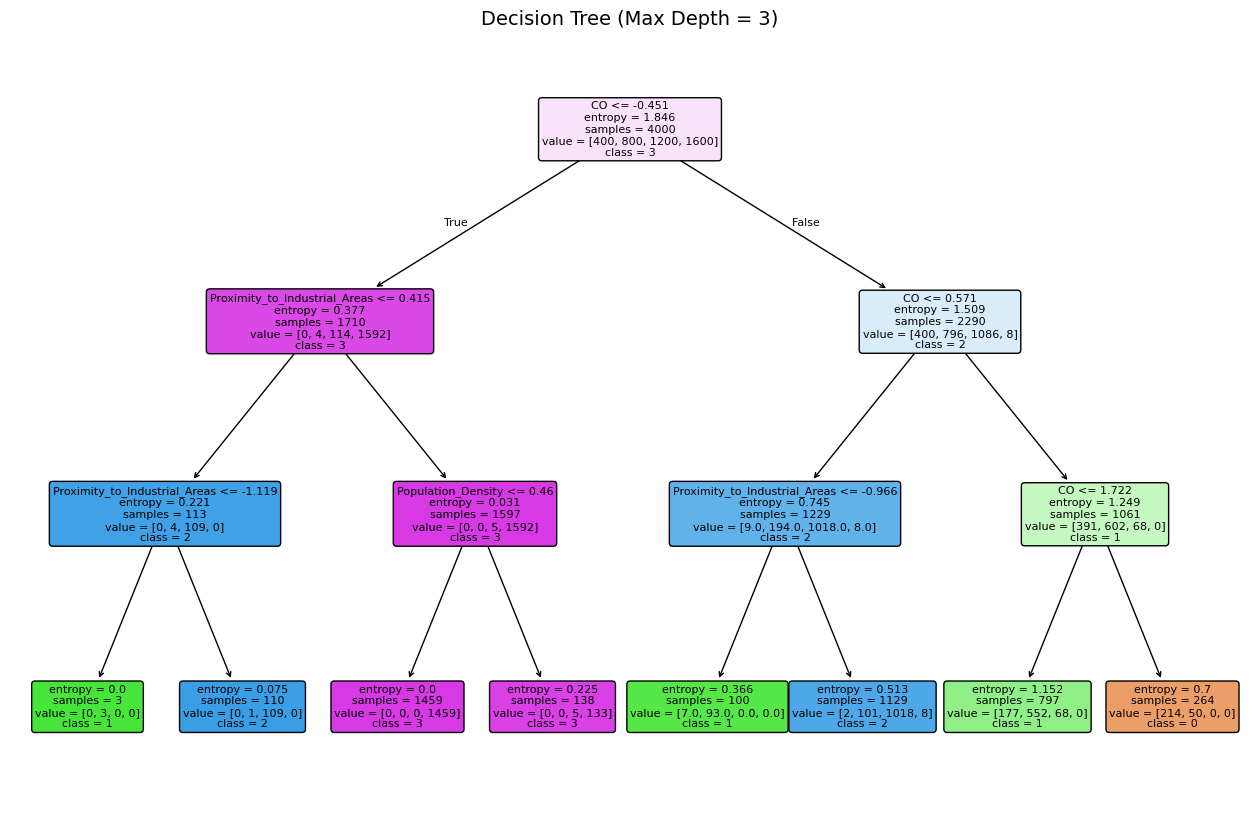

   depth  Accuracy  Precision  Recall  Macro F1  Micro F1
0      3    0.8860     0.8320  0.8212    0.8244    0.8860
1      5    0.9066     0.8799  0.8482    0.8582    0.9066
2     10    0.9274     0.8994  0.8922    0.8955    0.9274
3     30    0.9202     0.8865  0.8862    0.8861    0.9202
4     50    0.9202     0.8865  0.8862    0.8861    0.9202


In [20]:
# using all attributes
X = data.drop(columns="Air Quality")
y = data["Air Quality"]

# instantiate stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# List to store all results
results = []

# Loop over k values
for depth in [3, 5, 10, 30, 50]:
    dt = DecisionTreeClassifier(
    criterion="entropy",      # Different from default (gini)
    min_samples_split=4,      # Different from default (2)
    max_depth=depth,
    random_state=1
    )

    # Lists to store metrics per fold
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1_macros = []
    fold_f1_micros = []

    # Cross-validation folds
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # normalize the training set and the testing set based on the training set
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Train and predict
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_test)

        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        macrof1, microf1, _, _, _, pre, rec, _ = pre_rec_f1(y_pred, y_test)
        fold_accuracies.append(accuracy)
        fold_precisions.append(np.mean(pre))
        fold_recalls.append(np.mean(rec))
        fold_f1_macros.append(macrof1)
        fold_f1_micros.append(microf1)

    # Store averaged metrics in results list
    results.append({
        "depth": depth,
        "Accuracy": np.mean(fold_accuracies),
        "Precision": np.mean(fold_precisions),
        "Recall": np.mean(fold_recalls),
        "Macro F1": np.mean(fold_f1_macros),
        "Micro F1": np.mean(fold_f1_micros)
    })

    # plot the tree depth = 3
    if depth==3:
        plt.figure(figsize=(16, 10))
        plot_tree(
        dt,
        filled=True,
        feature_names=X.columns,
        class_names=[str(c) for c in np.unique(y)],
        rounded=True,
        fontsize=8
        )
        plt.title(f"Decision Tree (Max Depth = {depth})", fontsize=14)
        plt.show()

# Convert results to a DataFrame for neat tabular display
results_df = pd.DataFrame(results)

# Format numbers for readability
results_df[['Accuracy','Precision','Recall','Macro F1','Micro F1']] = results_df[
    ['Accuracy','Precision','Recall','Macro F1','Micro F1']].round(4)

print(results_df)

Task 3

In all of the following tasks, use StandardScaler to normalize the features before applying a classifier in the same way as Task 1.

A. Using all attributes, build an SVM model to predict Air Quality: Train the SVM model using the given kernel functions (linear, poly, rbf, sigmoid).

B. In the report, describe the values of model parameters that are set to be different from the default settings.

C. Perform 5-fold cross-validation for each of the 4 kernel functions and compute accuracy, precision, recall, macro-F1 and micro-F1. These metrics are average of the 5-fold validation sets. In each fold, precision and recall are averaged for all classes. Generate a table, as given below, for the obtained results.

In [21]:
X = data.drop(columns="Air Quality")
y = data["Air Quality"]

# Stratified 5-fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Store all results
results = []

# Loop over kernel types
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1_macros = []
    fold_f1_micros = []

    # Cross-validation
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # normalize the training set and the testing set based on the training set
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Initialize SVM model
        svm = SVC(kernel=kernel, random_state=1)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)

        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        macrof1, microf1, _, _, _, pre, rec, _ = pre_rec_f1(y_pred, y_test)

        fold_accuracies.append(accuracy)
        fold_precisions.append(np.mean(pre))
        fold_recalls.append(np.mean(rec))
        fold_f1_macros.append(macrof1)
        fold_f1_micros.append(microf1)

    # Store average metrics for this kernel
    results.append({
        "Kernel": kernel,
        "Accuracy": np.mean(fold_accuracies),
        "Precision": np.mean(fold_precisions),
        "Recall": np.mean(fold_recalls),
        "Macro F1": np.mean(fold_f1_macros),
        "Micro F1": np.mean(fold_f1_micros)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Format for readability
results_df[['Accuracy','Precision','Recall','Macro F1','Micro F1']] = results_df[
    ['Accuracy','Precision','Recall','Macro F1','Micro F1']].round(4)

print(results_df)

    Kernel  Accuracy  Precision  Recall  Macro F1  Micro F1
0   linear    0.9414     0.9211  0.9099    0.9151    0.9414
1     poly    0.9370     0.9220  0.9034    0.9114    0.9370
2      rbf    0.9456     0.9267  0.9160    0.9209    0.9456
3  sigmoid    0.7564     0.6104  0.6041    0.6063    0.7564


Task 4

In all of the following tasks, use StandardScaler to normalize the features before applying a classifier in the same way as Task 1.

A. Using all attributes, build a Bagging Classifier with Decision Tree as the base model to predict Air Quality: Train the Bagging Classifier using the given number of estimators (2, 5, 10, 100).

B. In the report, describe the values of model parameters that are set to be different from the default settings.

C. Perform 5-fold cross-validation for each of the 4 numbers of estimators and compute accuracy, precision, recall, macro-F1 and micro-F1. These metrics are average of the 5-fold validation sets. In each fold, precision and recall are averaged for all classes. Generate a table, as given below, for the obtained results.

In [22]:
X = data.drop(columns="Air Quality")
y = data["Air Quality"]

# Stratified 5-fold CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Store all results
results = []

# ====== Loop over number of estimators ======
for n_estimators in [2, 5, 10, 100]:
    # Base model: Decision Tree
    base_tree = DecisionTreeClassifier(
        criterion="entropy",   # default gini
        min_samples_split=4,   # default 2
        random_state=1
    )

    # Bagging Classifier
    bagging = BaggingClassifier(
        estimator=base_tree,
        n_estimators=n_estimators,
        random_state=1
    )

    # Lists to store per-fold metrics
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1_macros = []
    fold_f1_micros = []

    # Perform 5-fold CV
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # normalize the training set and the testing set based on the training set
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Train model
        bagging.fit(X_train, y_train)
        y_pred = bagging.predict(X_test)

        # Compute metrics
        accuracy = accuracy_score(y_test, y_pred)
        macrof1, microf1, _, _, _, pre, rec, _ = pre_rec_f1(y_pred, y_test)

        fold_accuracies.append(accuracy)
        fold_precisions.append(np.mean(pre))
        fold_recalls.append(np.mean(rec))
        fold_f1_macros.append(macrof1)
        fold_f1_micros.append(microf1)

    # Store average metrics for this estimator count
    results.append({
        "Estimators": n_estimators,
        "Accuracy": np.mean(fold_accuracies),
        "Precision": np.mean(fold_precisions),
        "Recall": np.mean(fold_recalls),
        "Macro F1": np.mean(fold_f1_macros),
        "Micro F1": np.mean(fold_f1_micros)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Round for readability
results_df[['Accuracy','Precision','Recall','Macro F1','Micro F1']] = results_df[
    ['Accuracy','Precision','Recall','Macro F1','Micro F1']].round(4)

print(results_df)

   Estimators  Accuracy  Precision  Recall  Macro F1  Micro F1
0           2    0.9142     0.8750  0.8945    0.8829    0.9142
1           5    0.9456     0.9243  0.9181    0.9210    0.9456
2          10    0.9476     0.9261  0.9207    0.9232    0.9476
3         100    0.9512     0.9318  0.9241    0.9277    0.9512


Task 5

In all of the following tasks, use StandardScaler to normalize the features before applying a classifier in the same way as Task 1.

A. Using all attributes, build a Gradient Boosting Classifier from sklearn to predict Air Quality: Train the Gradient Boosting Classifier using 100 estimators.

B. Using all attributes, build a LGBM Classifier from lightgbm to predict Air Quality: Train the LGBM Classifier using 100 estimators. (Note: check this slides for LGBM)

C. In the report, describe the values of model parameters that are set to be different from the default settings.

D. Perform 5-fold cross-validation for each of the two classifiers and compute accuracy, precision, recall, macro-F1 and micro-F1. These metrics are average of the 5-fold validation sets. In each fold, precision and recall are averaged for all classes. Generate a table, as given below, for the obtained results, and copy the results of Bagging Classifier with 100 estimators from Table 4.

In [ ]:
# data
X = data.drop(columns="Air Quality")
y = data["Air Quality"]

# Stratified 5-fold CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# models
models = {
    "Bagging (100 Estimators)": BaggingClassifier(
        estimator=DecisionTreeClassifier(
            criterion="entropy",
            min_samples_split=4,
            random_state=1
        ),
        n_estimators=100,
        random_state=1
    ),
    "Gradient Boosting (100 Estimators)": GradientBoostingClassifier(
        n_estimators=100,
        random_state=1
    ),
    "LightGBM (100 Estimators)": LGBMClassifier(
        n_estimators=100,
        random_state=1
    )
}

# cross validation
results = []

for name, model in models.items():
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1_macros = []
    fold_f1_micros = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # normalize the training set and the testing set based on the training set
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        macrof1, microf1, _, _, _, pre, rec, _ = pre_rec_f1(y_pred, y_test)

        fold_accuracies.append(accuracy)
        fold_precisions.append(np.mean(pre))
        fold_recalls.append(np.mean(rec))
        fold_f1_macros.append(macrof1)
        fold_f1_micros.append(microf1)

    results.append({
        "Classifier": name,
        "Accuracy": np.mean(fold_accuracies),
        "Precision": np.mean(fold_precisions),
        "Recall": np.mean(fold_recalls),
        "Macro F1": np.mean(fold_f1_macros),
        "Micro F1": np.mean(fold_f1_micros)
    })

# result to pandas dataframe
results_df = pd.DataFrame(results)

# Round for readability
results_df[['Accuracy', 'Precision', 'Recall', 'Macro F1', 'Micro F1']] = results_df[
    ['Accuracy', 'Precision', 'Recall', 'Macro F1', 'Micro F1']
].round(4)

print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2194
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 9
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2193
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 9
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2190
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 9
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2190
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 9
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2187
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 9
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
                           Classifier  Accuracy  Precision  Recall  Macro F1  \
0            Bagging (100 Estimators)    0.9512     0.9318  0.9241    0.9277   
1  Gradient Boosting (100 Estimators)    0.9558     0.9415  0.9316    0.9363   
2           LightGBM (100 Estimators)    0.9554     0.9396  0.9302    0.9345   

   Micro F1  
0    0.9512  
1    0.9558  
2    0.9554  


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
